# Data Analysis

Notebook sử dụng các helper dùng chung từ `utils/helper.py` để trực quan hóa ground truth, prediction và thống kê nhanh tập `train`/`val`.


In [1]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.helper import (
    bbox_center_x,
    bbox_center_y,
    bbox_iou,
    bbox_wh,
    draw_boxes_on_axis,
    load_split_annotations,
    show_groundtruth_slider,
    show_predictions_slider,
)

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Duyệt ground truth bằng slider dùng chung.
# Đổi folder thành "val" nếu muốn xem tập validation.
show_groundtruth_slider(folder="train")

# Duyệt kết quả detect bằng cùng slider viewer sau khi chạy predict.py.
predictions_path = PROJECT_ROOT / "saved_results" / "predictions.json"
if predictions_path.exists():
    show_predictions_slider(
        predictions_path,
        image_dir=PROJECT_ROOT / "public" / "val" / "images",
        classes_path=PROJECT_ROOT / "public" / "classes.json",
        show_ground_truth=True,
        ground_truth_path=PROJECT_ROOT / "public" / "annotations" / "val.json",
    )
else:
    print(f"Chưa có prediction file: {predictions_path}")


In [3]:
def show_stats(folder="train", data_root=None, area_thresholds=(32 * 32, 96 * 96)):
    """
    Thống kê và phân tích annotation cho tập train/val.

    area_thresholds dùng chuẩn COCO theo pixel:
    - Nhỏ: area < 32^2
    - Vừa: 32^2 <= area < 96^2
    - Lớn: area >= 96^2
    """
    root, split, data, images, annotations_by_image = load_split_annotations(folder, data_root)
    annotations = data["annotations"]

    num_images = len(images)
    num_boxes = len(annotations)
    box_counts = {image_id: len(annotations_by_image.get(image_id, [])) for image_id in images}
    min_box_count = min(box_counts.values()) if box_counts else 0
    max_box_count = max(box_counts.values()) if box_counts else 0
    min_box_images = [image_id for image_id, count in box_counts.items() if count == min_box_count]
    max_box_images = [image_id for image_id, count in box_counts.items() if count == max_box_count]

    print(f"Folder: {split}")
    print(f"Đường dẫn ảnh: {root / split / 'images'}")
    print(f"File annotation: {root / 'annotations' / f'{split}.json'}")
    print(f"Số ảnh: {num_images:,}")
    print(f"Số box: {num_boxes:,}")
    print(f"Ảnh ít box nhất: {min_box_count} box - {min_box_images[:10]}")
    print(f"Ảnh nhiều box nhất: {max_box_count} box - {max_box_images[:10]}")

    avg_objects_per_image = num_boxes / num_images if num_images else 0.0
    print(f"Số lượng vật thể trung bình / ảnh: {avg_objects_per_image:.3f}")

    adjacent_ious_x = []
    adjacent_ious_y = []
    adjacent_pairs_x = []
    adjacent_pairs_y = []
    for current_image_id, anns in annotations_by_image.items():
        sorted_by_x = sorted(anns, key=bbox_center_x)
        for left, right in zip(sorted_by_x, sorted_by_x[1:]):
            iou = bbox_iou(left["bbox"], right["bbox"])
            adjacent_ious_x.append(iou)
            adjacent_pairs_x.append((current_image_id, left, right, iou))

        sorted_by_y = sorted(anns, key=bbox_center_y)
        for top, bottom in zip(sorted_by_y, sorted_by_y[1:]):
            iou = bbox_iou(top["bbox"], bottom["bbox"])
            adjacent_ious_y.append(iou)
            adjacent_pairs_y.append((current_image_id, top, bottom, iou))

    adjacent_ious_xy = adjacent_ious_x + adjacent_ious_y
    mean_adjacent_iou_x = float(np.mean(adjacent_ious_x)) if adjacent_ious_x else 0.0
    mean_adjacent_iou_y = float(np.mean(adjacent_ious_y)) if adjacent_ious_y else 0.0
    mean_adjacent_iou_xy = float(np.mean(adjacent_ious_xy)) if adjacent_ious_xy else 0.0
    print(f"IoU chéo trung bình giữa các cặp vật thể liền kề theo trục x: {mean_adjacent_iou_x:.4f}")
    print(f"IoU chéo trung bình giữa các cặp vật thể liền kề theo trục y: {mean_adjacent_iou_y:.4f}")
    print(f"IoU chéo trung bình gộp x+y: {mean_adjacent_iou_xy:.4f}")
    print(f"Số cặp liền kề theo trục x: {len(adjacent_ious_x):,}")
    print(f"Số cặp liền kề theo trục y: {len(adjacent_ious_y):,}")

    class_counts = Counter(ann.get("class", "unknown") for ann in annotations)
    class_df = pd.DataFrame({"class": list(class_counts.keys()), "count": list(class_counts.values())}).sort_values("count", ascending=False)

    box_records = []
    small_thr, medium_thr = area_thresholds
    for ann in annotations:
        w, h = bbox_wh(ann["bbox"])
        area = w * h
        if area < small_thr:
            area_group = "Nhỏ"
        elif area < medium_thr:
            area_group = "Vừa"
        else:
            area_group = "Lớn"
        aspect_ratio = w / h if h > 0 else np.nan
        box_records.append(
            {
                "image_id": ann["image_id"],
                "class": ann.get("class", "unknown"),
                "w": w,
                "h": h,
                "aspect_ratio": aspect_ratio,
                "area": area,
                "area_group": area_group,
            }
        )
    box_df = pd.DataFrame(box_records)
    aspect_ratio_df = (
        box_df.dropna(subset=["aspect_ratio"])
        .groupby("class")["aspect_ratio"]
        .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
        .sort_values("median", ascending=False)
    )

    print("\nThống kê tỉ lệ w/h theo class:")
    display(aspect_ratio_df.round(3))

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    class_df.plot(kind="bar", x="class", y="count", legend=False, ax=axes[0], color="#4C78A8")
    axes[0].set_title("Số lần xuất hiện của class")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Số box")
    axes[0].tick_params(axis="x", rotation=30)

    area_order = ["Nhỏ", "Vừa", "Lớn"]
    area_counts = box_df["area_group"].value_counts().reindex(area_order, fill_value=0)
    area_counts.plot(kind="bar", ax=axes[1], color=["#59A14F", "#F28E2B", "#E15759"])
    axes[1].set_title("Phân nhóm diện tích bbox")
    axes[1].set_xlabel("Nhóm diện tích")
    axes[1].set_ylabel("Số box")
    axes[1].tick_params(axis="x", rotation=0)

    for group in area_order:
        subset = box_df[box_df["area_group"] == group]
        axes[2].scatter(subset["w"], subset["h"], s=16, alpha=0.45, label=f"{group} ({len(subset)})")
    axes[2].set_title("Scatter Plot: width vs height của bbox")
    axes[2].set_xlabel("Width")
    axes[2].set_ylabel("Height")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    class_order = aspect_ratio_df.index.tolist()
    data_by_class = [box_df.loc[box_df["class"] == cls, "aspect_ratio"].dropna() for cls in class_order]
    ax.boxplot(data_by_class, tick_labels=class_order, showfliers=False)
    ax.axhline(1.0, color="#E15759", linestyle="--", linewidth=1, label="w/h = 1")
    ax.set_title("Phân bố tỉ lệ w/h của bounding box theo class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Tỉ lệ w/h")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    representative_images = {}
    print("\nẢnh đại diện theo nhóm diện tích box:")
    for group in area_order:
        group_images = box_df.loc[box_df["area_group"] == group, "image_id"].drop_duplicates().head(3).tolist()
        representative_images[group] = group_images
        print(f"- {group}: {group_images}")

    if any(representative_images.values()):
        max_cols = 3
        rows = sum(1 for ids in representative_images.values() if ids)
        fig, axes = plt.subplots(rows, max_cols, figsize=(5 * max_cols, 4 * max(rows, 1)))
        axes = np.array(axes).reshape(rows, max_cols)
        row_idx = 0
        for group in area_order:
            ids = representative_images[group]
            if not ids:
                continue
            for col_idx in range(max_cols):
                ax = axes[row_idx, col_idx]
                if col_idx < len(ids):
                    current_image_id = ids[col_idx]
                    draw_boxes_on_axis(
                        ax,
                        root / images[current_image_id]["file_name"],
                        annotations_by_image.get(current_image_id, []),
                        classes=data["classes"],
                        title=f"{group}: {current_image_id}",
                    )
                else:
                    ax.axis("off")
            row_idx += 1
        plt.tight_layout()
        plt.show()

    summary = {
        "folder": split,
        "num_images": num_images,
        "num_boxes": num_boxes,
        "min_boxes": {"count": min_box_count, "image_ids": min_box_images},
        "max_boxes": {"count": max_box_count, "image_ids": max_box_images},
        "class_counts": class_counts,
        "area_counts": area_counts.to_dict(),
        "aspect_ratio_stats": aspect_ratio_df,
        "representative_images": representative_images,
        "avg_objects_per_image": avg_objects_per_image,
        "mean_adjacent_iou_x": mean_adjacent_iou_x,
        "mean_adjacent_iou_y": mean_adjacent_iou_y,
        "mean_adjacent_iou_xy": mean_adjacent_iou_xy,
        "adjacent_iou_count_x": len(adjacent_ious_x),
        "adjacent_iou_count_y": len(adjacent_ious_y),
        "adjacent_pairs_x": adjacent_pairs_x,
        "adjacent_pairs_y": adjacent_pairs_y,
        "box_dataframe": box_df,
        "class_dataframe": class_df,
    }
    return summary

Folder: train
Đường dẫn ảnh: /Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/public/train/images
File annotation: /Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/public/annotations/train.json
Số ảnh: 7,500
Số box: 10,642
Ảnh ít box nhất: 0 box - ['img_001a4e7e3117.jpg', 'img_00229a7b1efe.jpg', 'img_0023f550d4f3.jpg', 'img_003466508997.jpg', 'img_00361fbf8a6f.jpg', 'img_003c7bee81c8.jpg', 'img_00533da25c53.jpg', 'img_00601a320e1d.jpg', 'img_00602bbde2d6.jpg', 'img_006eea42d642.jpg']
Ảnh nhiều box nhất: 22 box - ['img_3e944cd7cf6d.jpg']
Số lượng vật thể trung bình / ảnh: 1.419
IoU chéo trung bình giữa các cặp vật thể liền kề theo trục x: 0.1136
IoU chéo trung bình giữa các cặp vật thể liền kề theo trục y: 0.0809
IoU chéo trung bình gộp x+y: 0.0973
Số cặp liền kề theo trục x: 5,642
Số cặp liền kề theo trục y: 5,642

Thống kê tỉ lệ w/h theo class:


,count,mean,median,std,min,max
class,,,,,,
car,1339,1.690,1.586,0.718,0.250,4.850
cat,833,1.208,1.158,0.511,0.292,4.949
dog,1028,1.116,1.042,0.461,0.268,3.014
chair,1613,0.900,0.772,0.518,0.123,5.667
person,5829,0.665,0.591,0.351,0.080,3.732


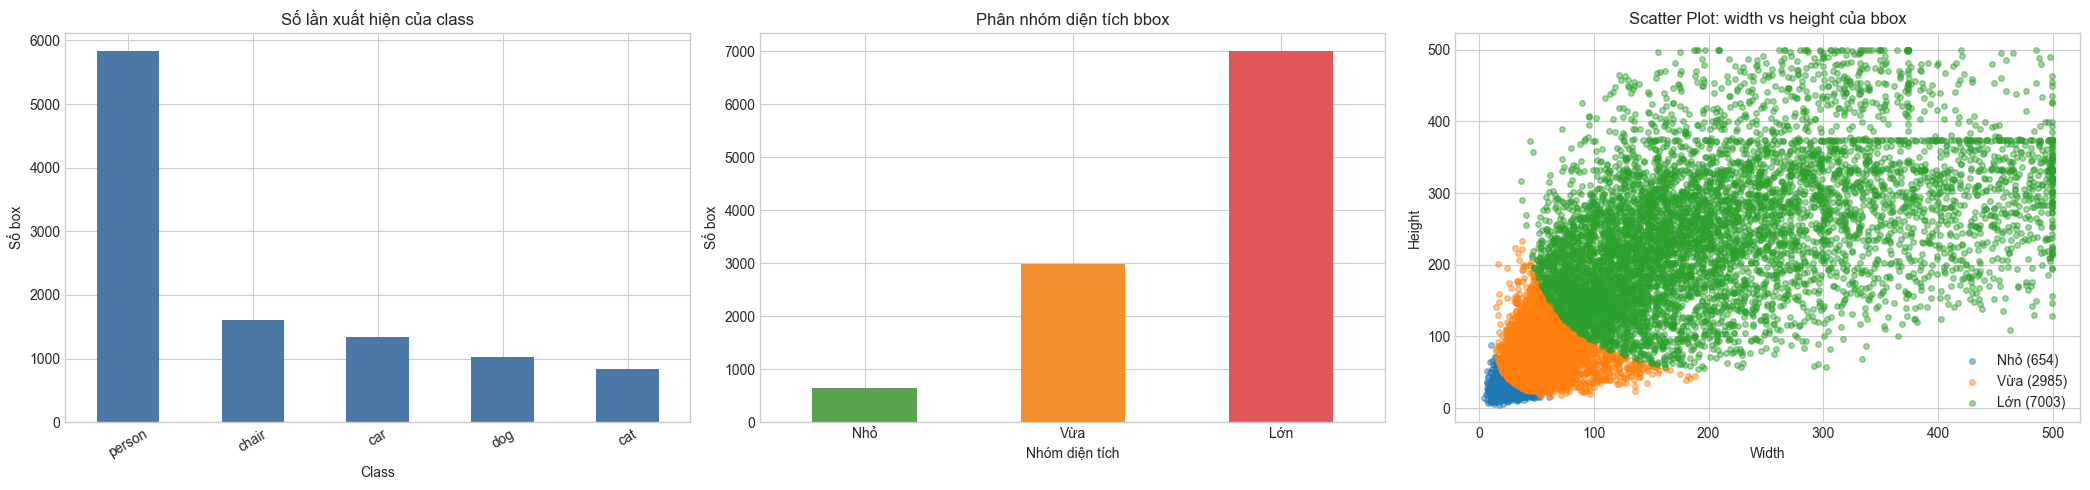

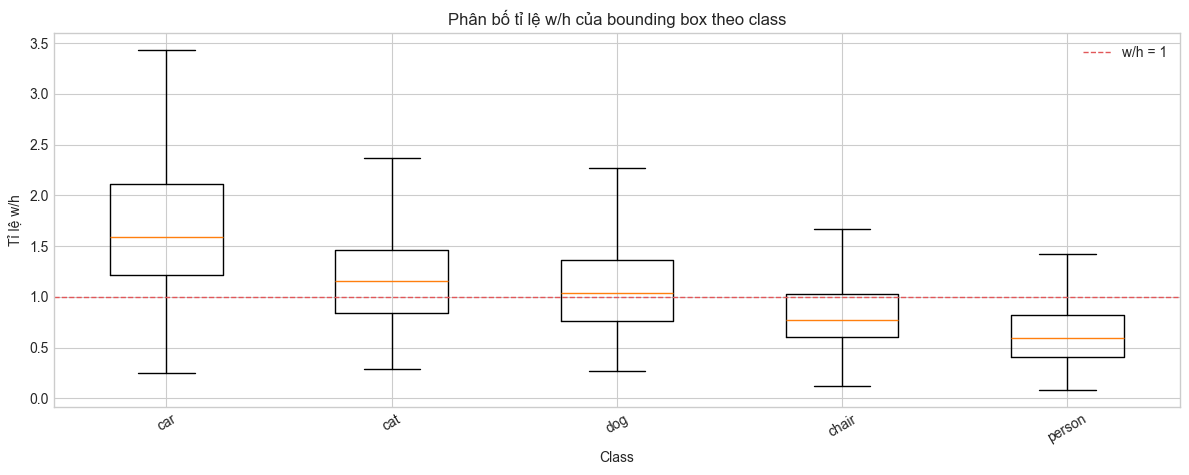


Ảnh đại diện theo nhóm diện tích box:
- Nhỏ: ['img_024fd087912c.jpg', 'img_03c641913334.jpg', 'img_04988c52869b.jpg']
- Vừa: ['img_00867fa92281.jpg', 'img_00c55347b9ce.jpg', 'img_00eb18a87046.jpg']
- Lớn: ['img_000c52c6d12f.jpg', 'img_0011ca268442.jpg', 'img_0052bf863a61.jpg']


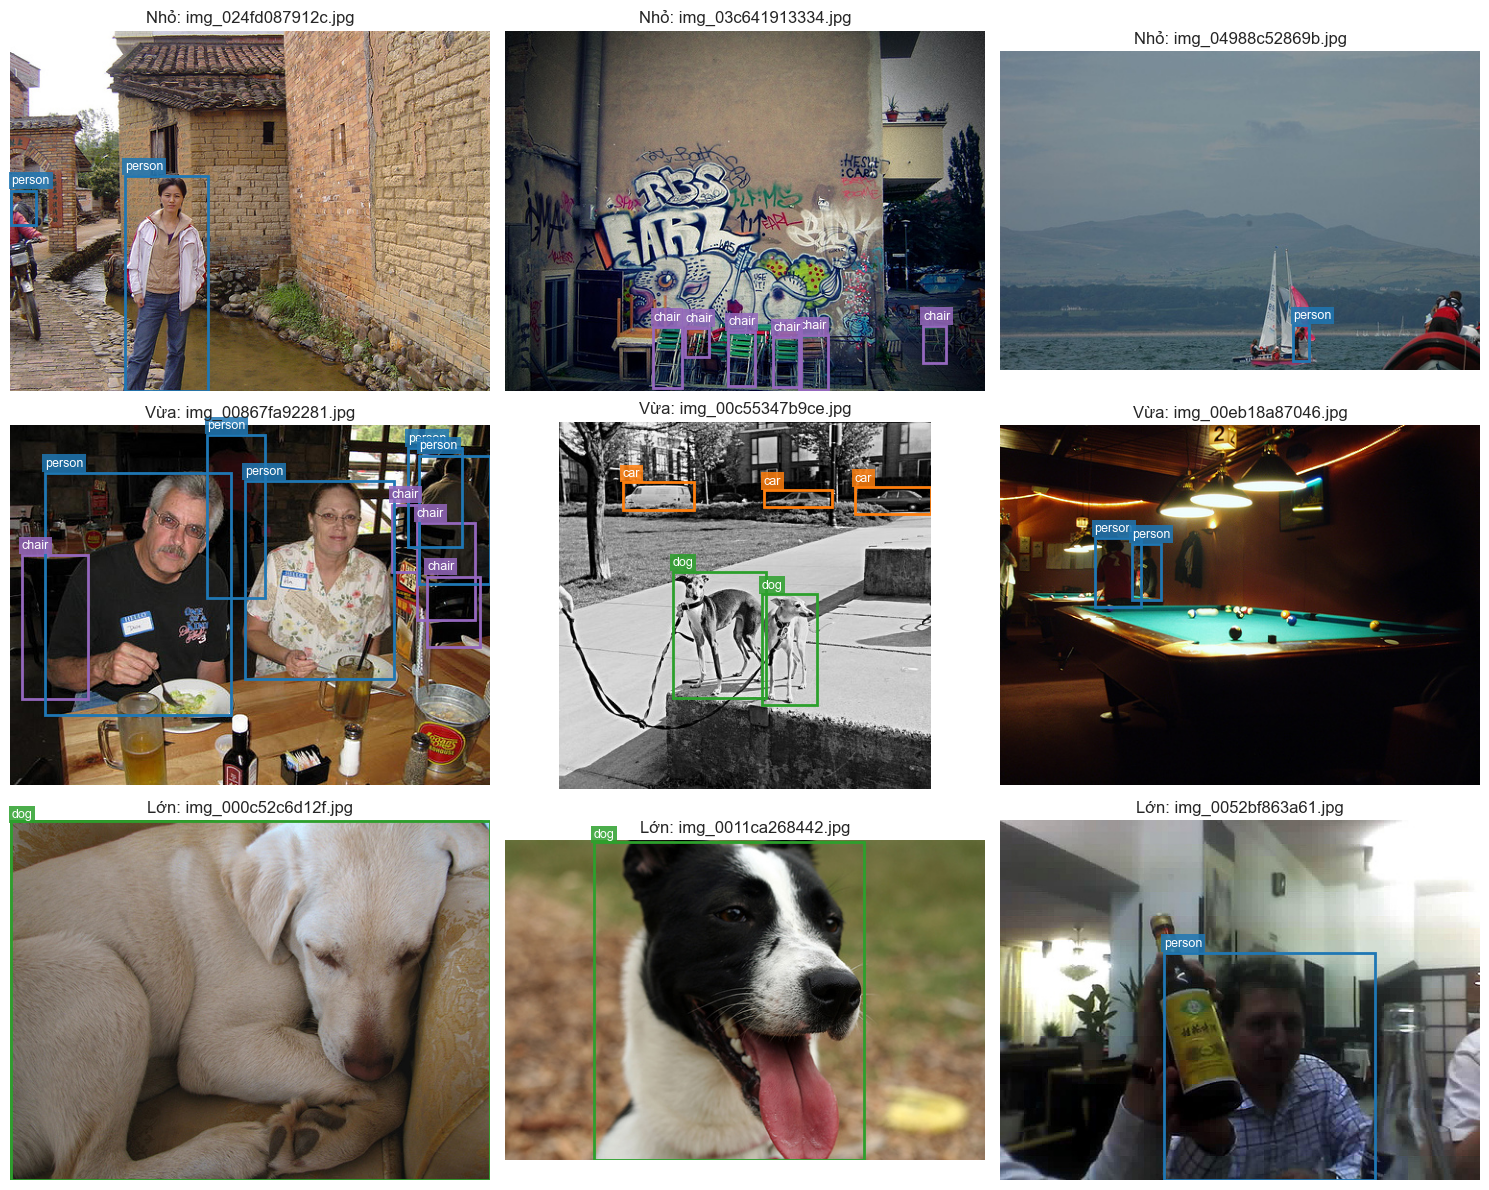

{'folder': 'train',
 'num_images': 7500,
 'num_boxes': 10642,
 'min_boxes': {'count': 0,
  'image_ids': ['img_001a4e7e3117.jpg',
   'img_00229a7b1efe.jpg',
   'img_0023f550d4f3.jpg',
   'img_003466508997.jpg',
   'img_00361fbf8a6f.jpg',
   'img_003c7bee81c8.jpg',
   'img_00533da25c53.jpg',
   'img_00601a320e1d.jpg',
   'img_00602bbde2d6.jpg',
   'img_006eea42d642.jpg',
   'img_00a4428a6974.jpg',
   'img_00c8010219ff.jpg',
   'img_00dc08ad3537.jpg',
   'img_012bd2619824.jpg',
   'img_0136c2266a58.jpg',
   'img_013d7e97741a.jpg',
   'img_014777e70743.jpg',
   'img_014c5ccecd86.jpg',
   'img_01580a2e04cc.jpg',
   'img_019273cd412a.jpg',
   'img_01e6511fee1d.jpg',
   'img_01ea2cdaccff.jpg',
   'img_0203f3e9b538.jpg',
   'img_02404c087152.jpg',
   'img_024735d275db.jpg',
   'img_02481c8cbea7.jpg',
   'img_026a2ffbca88.jpg',
   'img_026c817695d5.jpg',
   'img_028af7d4b617.jpg',
   'img_0290140536ca.jpg',
   'img_02972cb74984.jpg',
   'img_02ff31dd11de.jpg',
   'img_0305b312f1d9.jpg',
   'img

In [4]:
show_stats("train")